## 1. Импорт библиотек и настройки

In [ ]:
import warnings
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
DATA_PATH = Path("train.csv")
TARGET = "target"

sns.set_theme(style="whitegrid", font_scale=1.05)
pd.set_option("display.max_columns", 120)

## 2. Загрузка данных

В датасете 36 671 объявление и 15 исходных столбцов. Данные подходят для кластеризации,
потому что в них есть разные типы признаков, по которым объявления могут естественно
разделяться на группы: география (`lat`, `lon`, `location_cluster`, `location`), тип жилья
(`type_house`), цена (`sum`), условия аренды (`min_days`), активность отзывов
(`amt_reviews`, `avg_reviews`, `last_dt`) и масштаб хоста (`total_host`).

`last_dt` и `avg_reviews` имеют по 7 502 пропуска, то есть 20.46%.
Это не просто технические пропуски: скорее всего, они означают отсутствие отзывов. Поэтому
факт пропуска был превращен в отдельные признаки.

In [ ]:
df = pd.read_csv(DATA_PATH)
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
display(df.head())

Размер датасета: 36671 строк, 15 столбцов


,name,_id,host_name,location_cluster,location,lat,lon,type_house,sum,min_days,amt_reviews,last_dt,avg_reviews,total_host,target
0,Belle Harbor 4 BR 2 bath- 1 bl from Beach,40327248,Sarina,Queens,Neponsit,40.57215,-73.85822,Entire home/apt,350,2,5,2019-07-07,2.88,1,334
1,"Come see Brooklyn, New York",13617520,Howard T.,Brooklyn,Clinton Hill,40.69172,-73.96934,Shared room,40,5,8,2015-02-25,0.13,1,0
2,Large 2Br on W71st & Columbus Feb 19-28,26754726,Julie,Manhattan,Upper West Side,40.77673,-73.98011,Entire home/apt,200,5,0,NaN,NaN,1,0
3,Perfect bedroom. Near Subways Columbia CityCol...,16721721,Federico,Manhattan,Harlem,40.81530,-73.95080,Private room,65,2,18,2018-11-04,0.64,1,0
4,Cozy Sun Filled Fresh Guest Room in Artsy Bush...,22246463,Lisa,Brooklyn,Bushwick,40.70230,-73.92935,Private room,99,2,26,2019-06-23,0.76,1,155


In [ ]:
info_table = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_share": (df.isna().mean() * 100).round(2),
    "nunique": df.nunique(),
})
display(info_table)
display(df[[TARGET, "sum", "min_days", "amt_reviews", "avg_reviews", "total_host"]].describe().T)

,dtype,missing,missing_share,nunique
name,str,9,0.02,36076
_id,int64,0,0.00,29141
host_name,str,18,0.05,9629
location_cluster,str,0,0.00,5
location,str,0,0.00,220
lat,float64,0,0.00,16968
lon,float64,0,0.00,13295
type_house,str,0,0.00,3
sum,int64,0,0.00,625
min_days,int64,0,0.00,96


,count,mean,std,min,25%,50%,75%,max
target,36671.0,112.766628,131.583284,0.00,0.00,45.00,227.00,365.00
sum,36671.0,152.142292,239.107973,0.00,69.00,106.00,175.00,10000.00
min_days,36671.0,7.053176,21.539569,1.00,1.00,3.00,5.00,1250.00
amt_reviews,36671.0,23.433667,44.703590,0.00,1.00,5.00,24.00,629.00
avg_reviews,29169.0,1.365601,1.643966,0.01,0.19,0.72,2.01,20.94
total_host,36671.0,7.047694,32.595427,1.00,1.00,1.00,2.00,327.00


## 3. Подготовка признаков

Перед кластеризацией все признаки приведены к числовому виду. Это обязательно, потому что
K-Means, GMM, DBSCAN и Agglomerative Clustering работают с расстояниями между объектами.
Строковые категории напрямую в расстояния подставить нельзя.

Категориальные признаки `location_cluster`, `location` и `type_house` закодированы через
one-hot encoding. Это корректнее, чем заменить категории числами, потому что между районами
или типами жилья нет естественного порядка. Например, `Manhattan` не должен быть "больше"
или "меньше", чем `Brooklyn`.

Числовые признаки стандартизированы. Это нужно, чтобы признаки с большим масштабом, например
`sum` или `min_days`, не доминировали над признаками вроде `avg_reviews`. После подготовки
кластеры строятся не по одной крупной величине, а по общей структуре всех признаков.

In [ ]:
reference_date = pd.to_datetime(df["last_dt"], errors="coerce").max() + pd.Timedelta(days=1)


def add_features(X):
    X = X.copy()
    last_dt = pd.to_datetime(X["last_dt"], errors="coerce")
    name = X["name"].fillna("")
    host_name = X["host_name"].fillna("")

    X["name_len"] = name.str.len()
    X["name_words"] = name.str.split().str.len().fillna(0)
    X["host_name_len"] = host_name.str.len()
    X["last_dt_missing"] = last_dt.isna().astype(int)
    X["last_review_age"] = (reference_date - last_dt).dt.days
    X["last_review_year"] = last_dt.dt.year
    X["last_review_month"] = last_dt.dt.month
    X["avg_reviews_missing"] = X["avg_reviews"].isna().astype(int)
    X["has_reviews"] = (X["amt_reviews"] > 0).astype(int)
    X["reviews_per_host_listing"] = X["amt_reviews"] / (X["total_host"] + 1)
    X["sum_per_min_day"] = X["sum"] / (X["min_days"] + 1)
    X["lat_lon_product"] = X["lat"] * X["lon"]

    return X.drop(columns=["name", "host_name", "last_dt", "_id"], errors="ignore")


X_raw = df.drop(columns=[TARGET])
X = add_features(X_raw)

categorical_features = ["location_cluster", "location", "type_house"]
numeric_features = [col for col in X.columns if col not in categorical_features]

print("Категориальные признаки:", categorical_features)
print("Числовые признаки:", numeric_features)
display(X.head())

Категориальные признаки: ['location_cluster', 'location', 'type_house']
Числовые признаки: ['lat', 'lon', 'sum', 'min_days', 'amt_reviews', 'avg_reviews', 'total_host', 'name_len', 'name_words', 'host_name_len', 'last_dt_missing', 'last_review_age', 'last_review_year', 'last_review_month', 'avg_reviews_missing', 'has_reviews', 'reviews_per_host_listing', 'sum_per_min_day', 'lat_lon_product']


,location_cluster,location,lat,lon,type_house,sum,min_days,amt_reviews,avg_reviews,total_host,name_len,name_words,host_name_len,last_dt_missing,last_review_age,last_review_year,last_review_month,avg_reviews_missing,has_reviews,reviews_per_host_listing,sum_per_min_day,lat_lon_product
0,Queens,Neponsit,40.57215,-73.85822,Entire home/apt,350,2,5,2.88,1,41,10,6,0,2.0,2019.0,7.0,0,1,2.5,116.666667,-2996.586781
1,Brooklyn,Clinton Hill,40.69172,-73.96934,Shared room,40,5,8,0.13,1,27,5,9,0,1595.0,2015.0,2.0,0,1,4.0,6.666667,-3009.939672
2,Manhattan,Upper West Side,40.77673,-73.98011,Entire home/apt,200,5,0,NaN,1,39,8,5,1,NaN,NaN,NaN,1,0,0.0,33.333333,-3016.666971
3,Manhattan,Harlem,40.81530,-73.95080,Private room,65,2,18,0.64,1,50,6,8,0,247.0,2018.0,11.0,0,1,9.0,21.666667,-3018.324087
4,Brooklyn,Bushwick,40.70230,-73.92935,Private room,99,2,26,0.76,1,50,9,4,0,16.0,2019.0,6.0,0,1,13.0,33.000000,-3009.094583


In [ ]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

X_prepared = preprocessor.fit_transform(X)
print("Размер матрицы после кодирования:", X_prepared.shape)

Размер матрицы после кодирования: (36671, 247)


## 4. Снижение размерности через PCA

Хотя в исходном датасете 15 столбцов, после feature engineering и one-hot кодирования
признаков становится значительно больше. Особенно сильно размерность увеличивает `location`,
потому что в нем 220 уникальных значений.

PCA был применен, чтобы сжать расширенное признаковое пространство до меньшего числа компонент
и убрать часть шума. В результате выбрано 11 PCA-компонент, которые сохраняют 87.6% дисперсии
данных. Это хороший компромисс: размерность сильно уменьшается, но большая часть информации
сохраняется.

Для кластеризации это полезно по трем причинам: алгоритмы работают быстрее, расстояния становятся
стабильнее, а первые две PCA-компоненты можно использовать для визуализации кластеров.

In [ ]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_prepared)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

n_components = int(np.searchsorted(cumulative_variance, 0.85) + 1)
n_components = min(max(n_components, 8), 25)
print(f"Выбрано компонент PCA: {n_components}")
print(f"Доля объясненной дисперсии: {cumulative_variance[n_components - 1]:.3f}")

pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_prepared)

Выбрано компонент PCA: 11
Доля объясненной дисперсии: 0.876


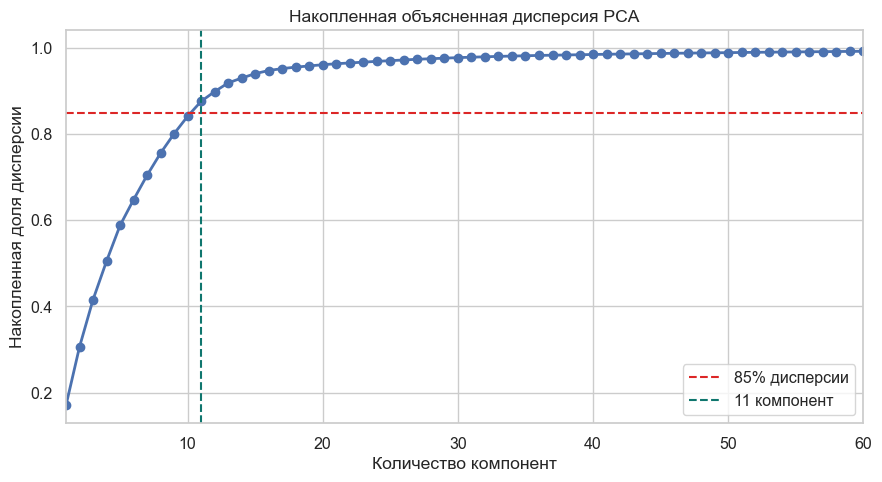

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(np.arange(1, len(cumulative_variance) + 1), cumulative_variance, marker="o", linewidth=2)
ax.axhline(0.85, color="#dc2626", linestyle="--", label="85% дисперсии")
ax.axvline(n_components, color="#0f766e", linestyle="--", label=f"{n_components} компонент")
ax.set_title("Накопленная объясненная дисперсия PCA")
ax.set_xlabel("Количество компонент")
ax.set_ylabel("Накопленная доля дисперсии")
ax.set_xlim(1, min(60, len(cumulative_variance)))
ax.legend()
plt.tight_layout()
plt.show()

## 5. Подбор числа кластеров для K-Means

Для K-Means были проверены значения `k` от 2 до 8. Метрики показали неоднозначную картину:

| k | Silhouette | Davies-Bouldin | Комментарий |
|---:|---:|---:|---|
| 2 | 0.276 | 1.422 | лучший Silhouette, но слишком грубое разбиение |
| 6 | 0.226 | 1.379 | более детальная сегментация |
| 7 | 0.228 | 1.236 | лучший Davies-Bouldin |
| 8 | 0.213 | 1.295 | хуже, чем k=7 по DB |

По результатам анализа выбран **K-Means с `k=7`**.

Почему не просто `k=2`: при `k=2` silhouette выше, но разбиение слишком общее и дает мало
аналитической пользы. Для задания по кластеризации важно показать содержательные группы,
а не только формально максимизировать одну метрику.

Почему `k=7`: среди рассмотренных значений `k` этот вариант дает лучший Davies-Bouldin index.
Эта метрика оценивает компактность кластеров и их отделимость друг от друга: чем она ниже,
тем лучше. Поэтому `k=7` выглядит разумным выбором для более подробной сегментации объявлений.

Минус `k=7`: появляется очень маленький кластер с долей 0.14%. Это не ошибка, а сигнал
о наличии нетипичной группы объектов. Поэтому дальше такие малые кластеры нужно интерпретировать
аккуратно: они могут быть специфическими сегментами или выбросами.

In [ ]:
rng = np.random.default_rng(RANDOM_STATE)
eval_size = min(6000, len(X_pca))
eval_idx = rng.choice(len(X_pca), size=eval_size, replace=False)
X_eval = X_pca[eval_idx]

kmeans_rows = []
kmeans_models = {}

for k in range(2, 9):
    start = perf_counter()
    model = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = model.fit_predict(X_pca)
    elapsed = perf_counter() - start
    eval_labels = labels[eval_idx]

    kmeans_rows.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X_eval, eval_labels),
        "davies_bouldin": davies_bouldin_score(X_eval, eval_labels),
        "calinski_harabasz": calinski_harabasz_score(X_eval, eval_labels),
        "min_cluster_share": pd.Series(labels).value_counts(normalize=True).min(),
        "fit_seconds": elapsed,
    })
    kmeans_models[k] = (model, labels)

kmeans_eval = pd.DataFrame(kmeans_rows)
display(kmeans_eval)

,k,inertia,silhouette,davies_bouldin,calinski_harabasz,min_cluster_share,fit_seconds
0,2,556106.012844,0.276363,1.422381,1382.778916,0.204739,2.318191
1,3,488685.211443,0.217523,1.738910,1212.563409,0.204576,0.257866
2,4,442564.407272,0.233318,1.541485,1116.735154,0.099397,0.328479
3,5,405324.141412,0.214284,1.584139,1075.017694,0.076845,0.347236
4,6,372645.482546,0.225777,1.378511,1065.252057,0.011290,0.670115
5,7,354114.688743,0.228310,1.235726,944.585458,0.001391,0.689997
6,8,324847.152839,0.213231,1.294709,972.107828,0.001309,0.917204


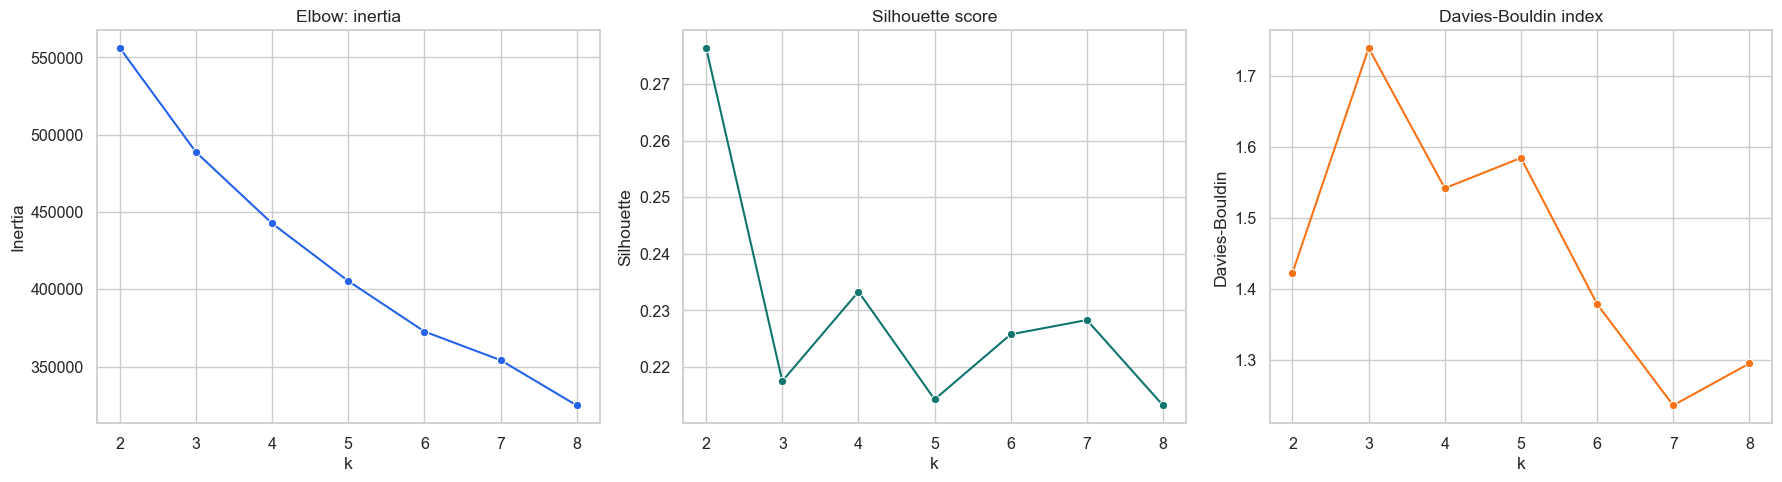

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.lineplot(data=kmeans_eval, x="k", y="inertia", marker="o", ax=axes[0], color="#2563eb")
axes[0].set_title("Elbow: inertia")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

sns.lineplot(data=kmeans_eval, x="k", y="silhouette", marker="o", ax=axes[1], color="#0f766e")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")

sns.lineplot(data=kmeans_eval, x="k", y="davies_bouldin", marker="o", ax=axes[2], color="#f97316")
axes[2].set_title("Davies-Bouldin index")
axes[2].set_xlabel("k")
axes[2].set_ylabel("Davies-Bouldin")

plt.tight_layout()
plt.show()

In [ ]:
best_k = 7

best_kmeans, best_kmeans_labels = kmeans_models[best_k]
best_k_row = kmeans_eval.loc[kmeans_eval["k"].eq(best_k)].iloc[0]

print(f"Выбранное число кластеров для K-Means: {best_k}")
print(f"Silhouette при k={best_k}: {best_k_row['silhouette']:.3f}")
print(f"Davies-Bouldin при k={best_k}: {best_k_row['davies_bouldin']:.3f}")
print(f"Минимальная доля кластера при k={best_k}: {best_k_row['min_cluster_share']:.4f}")

Выбранное число кластеров для K-Means: 7
Silhouette при k=7: 0.228
Davies-Bouldin при k=7: 1.236
Минимальная доля кластера при k=7: 0.0014


## 6. Сравнение методов кластеризации

В работе сравнивались четыре метода кластеризации:

| Метод | Почему использован | Итог |
|---|---|---|
| K-Means | быстрый разделительный метод для всего датасета | выбран как основной |
| GMM | вероятностная альтернатива K-Means | хуже на k=7 по метрикам |
| Agglomerative | иерархический метод для сравнения структуры | близок, но только на sample |
| DBSCAN | плотностный метод, умеет находить шум | хороший silhouette, но хуже DB/CH и зависит от eps |

DBSCAN имеет самый высокий silhouette среди сравниваемых методов
на подвыборке: 0.269. Но это не делает его лучшим выбором для финальной работы: он обучался
только на sample, нашел 5 кластеров вместо выбранных 7, выделил шум и имеет заметно худшие
Davies-Bouldin и Calinski-Harabasz.

K-Means с `k=7` имеет silhouette 0.228, Davies-Bouldin 1.236 и Calinski-Harabasz 944.585.
Среди методов с 7 кластерами он лучше GMM и Agglomerative по Davies-Bouldin и Calinski-Harabasz.
Главное преимущество K-Means — он применен ко всему датасету и дает понятную сегментацию
каждого объявления.

GMM с 7 компонентами показал слабее результат: silhouette 0.134 и Davies-Bouldin 2.710.
Это говорит о том, что предположение о гауссовских компонентах плохо подходит для этих
подготовленных табличных данных. Agglomerative Clustering дал silhouette 0.199 и DB 1.362,
но из-за вычислительной сложности использовался только на 6 000 объектов. Поэтому для всей
выборки он менее практичен.


По результатам сравнения K-Means выбран как основной метод по следующим причинам:

1. **Масштабируемость.** Датасет содержит 36 671 объект. K-Means спокойно обучается
на всех данных, в отличие от иерархической кластеризации и плотностных методов,
которые на полной выборке становятся заметно тяжелее.

2. **Подходящий формат данных.** После кодирования категорий, стандартизации числовых
признаков и PCA объекты представлены в числовом евклидовом пространстве. Это именно
тот формат, для которого K-Means является естественным базовым методом.

3. **Интерпретируемость.** Кластеры K-Means легко профилировать через средние значения
признаков, распределение типов жилья и районов. Для учебной задачи это важно, потому
что нужно не только получить метки, но и объяснить смысл групп.

4. **Сравнение с альтернативами.** GMM дает более гибкую вероятностную модель, но
сильнее зависит от предположения о гауссовской форме компонент. Agglomerative хорошо
подходит для анализа структуры на малых данных, но плохо масштабируется. DBSCAN полезен
для поиска плотных областей и шума, но на этих данных чувствителен к выбору `eps`
и может давать неудобные по размеру кластеры.

Итог: для данного табличного датасета Airbnb наиболее разумный выбор — K-Means после
подготовки признаков и PCA. Это не означает, что K-Means всегда лучший метод, но здесь
он дает лучший баланс качества, скорости, простоты и интерпретируемости.

In [ ]:
def evaluate_labels(name, labels, X_metric, fit_seconds, full_data=True):
    labels = np.asarray(labels)
    unique_labels = set(labels)
    noise_share = float(np.mean(labels == -1)) if -1 in unique_labels else 0.0
    cluster_labels = [label for label in unique_labels if label != -1]
    n_clusters = len(cluster_labels)

    result = {
        "method": name,
        "scope": "all_data" if full_data else "sample",
        "n_clusters": n_clusters,
        "noise_share": noise_share,
        "silhouette": np.nan,
        "davies_bouldin": np.nan,
        "calinski_harabasz": np.nan,
        "fit_seconds": fit_seconds,
    }

    if len(np.unique(labels)) > 1:
        result["silhouette"] = silhouette_score(X_metric, labels)
        result["davies_bouldin"] = davies_bouldin_score(X_metric, labels)
        result["calinski_harabasz"] = calinski_harabasz_score(X_metric, labels)

    return result


comparison_rows = []

comparison_rows.append(evaluate_labels(
    f"K-Means k={best_k}",
    best_kmeans_labels[eval_idx],
    X_eval,
    kmeans_eval.loc[kmeans_eval["k"].eq(best_k), "fit_seconds"].iloc[0],
    full_data=True,
))

start = perf_counter()
gmm = GaussianMixture(
    n_components=best_k,
    covariance_type="diag",
    random_state=RANDOM_STATE,
    max_iter=200,
    n_init=3,
)
gmm_labels = gmm.fit_predict(X_pca)
gmm_seconds = perf_counter() - start
comparison_rows.append(evaluate_labels(
    f"GMM components={best_k}",
    gmm_labels[eval_idx],
    X_eval,
    gmm_seconds,
    full_data=True,
))

start = perf_counter()
agg = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
agg_labels = agg.fit_predict(X_eval)
agg_seconds = perf_counter() - start
comparison_rows.append(evaluate_labels(
    f"Agglomerative k={best_k}",
    agg_labels,
    X_eval,
    agg_seconds,
    full_data=False,
))

nn = NearestNeighbors(n_neighbors=10)
nn.fit(X_eval)
distances, _ = nn.kneighbors(X_eval)
kth_distances = distances[:, -1]

dbscan_candidates = []
for q in [0.70, 0.80, 0.90, 0.95]:
    eps = float(np.quantile(kth_distances, q))
    start = perf_counter()
    db = DBSCAN(eps=eps, min_samples=10)
    labels = db.fit_predict(X_eval)
    elapsed = perf_counter() - start
    row = evaluate_labels(
        f"DBSCAN eps=q{q:.2f}",
        labels,
        X_eval,
        elapsed,
        full_data=False,
    )
    row["eps"] = eps
    dbscan_candidates.append(row)

dbscan_table = pd.DataFrame(dbscan_candidates)
display(dbscan_table)

valid_dbscan = dbscan_table[(dbscan_table["n_clusters"] >= 2) & (dbscan_table["noise_share"] < 0.8)]
if len(valid_dbscan) > 0:
    best_dbscan_row = valid_dbscan.sort_values(["silhouette", "davies_bouldin"], ascending=[False, True]).iloc[0].to_dict()
else:
    best_dbscan_row = dbscan_table.iloc[0].to_dict()

comparison_rows.append(best_dbscan_row)

comparison = pd.DataFrame(comparison_rows)
display(comparison.sort_values("silhouette", ascending=False))

,method,scope,n_clusters,noise_share,silhouette,davies_bouldin,calinski_harabasz,fit_seconds,eps
0,DBSCAN eps=q0.70,sample,6,0.145500,0.215974,2.248878,312.301229,0.362111,1.596828
1,DBSCAN eps=q0.80,sample,5,0.092833,0.252471,2.328392,383.427628,0.414104,1.781990
2,DBSCAN eps=q0.90,sample,5,0.046500,0.265081,2.116014,399.932918,0.471990,2.141796
3,DBSCAN eps=q0.95,sample,5,0.024833,0.268537,2.035390,402.732044,0.610627,2.592836


,method,scope,n_clusters,noise_share,silhouette,davies_bouldin,calinski_harabasz,fit_seconds,eps
3,DBSCAN eps=q0.95,sample,5,0.024833,0.268537,2.035390,402.732044,0.610627,2.592836
0,K-Means k=7,all_data,7,0.000000,0.228310,1.235726,944.585458,0.689997,NaN
2,Agglomerative k=7,sample,7,0.000000,0.199107,1.361878,864.399782,0.679679,NaN
1,GMM components=7,all_data,7,0.000000,0.133798,2.710374,574.656335,1.625172,NaN


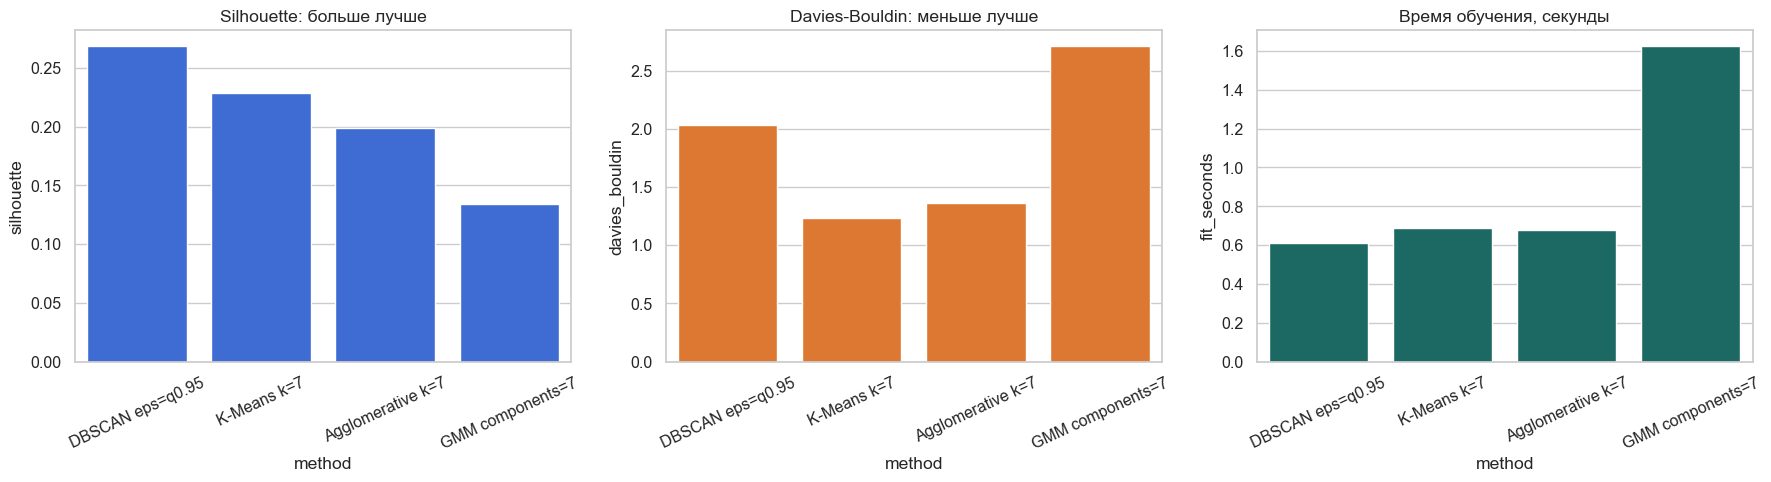

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ordered = comparison.sort_values("silhouette", ascending=False)

sns.barplot(data=ordered, x="method", y="silhouette", ax=axes[0], color="#2563eb")
axes[0].set_title("Silhouette: больше лучше")
axes[0].tick_params(axis="x", rotation=25)

sns.barplot(data=ordered, x="method", y="davies_bouldin", ax=axes[1], color="#f97316")
axes[1].set_title("Davies-Bouldin: меньше лучше")
axes[1].tick_params(axis="x", rotation=25)

sns.barplot(data=ordered, x="method", y="fit_seconds", ax=axes[2], color="#0f766e")
axes[2].set_title("Время обучения, секунды")
axes[2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

## 7. Финальная кластеризация выбранным методом

K-Means с `k=7` выделил следующие размеры кластеров:

| Кластер | Размер | Доля |
|---:|---:|---:|
| 0 | 10 779 | 29.39% |
| 1 | 5 456 | 14.88% |
| 2 | 2 816 | 7.68% |
| 3 | 7 242 | 19.75% |
| 4 | 9 913 | 27.03% |
| 5 | 414 | 1.13% |
| 6 | 51 | 0.14% |

Интерпретация по профилям:

- Кластер 0: массовый сегмент Brooklyn/Private room, сравнительно низкая цена, средняя
  активность отзывов, `mean_target` около 128.8.
- Кластер 1: сегмент с низкой активностью отзывов и низким `target`; медианный `target` равен 0.
- Кластер 2: объявления с очень большим числом отзывов, высокой `avg_reviews` и высоким
  `target`; это активный и востребованный сегмент.
- Кластер 3: объявления без отзывов (`amt_reviews = 0`), чаще `Entire home/apt`, с низкой
  медианой `target`.
- Кластер 4: крупный Manhattan/Harlem-сегмент с более высокой ценой и умеренной активностью.
- Кластер 5: маленький сегмент дорогих объявлений с очень большим `total_host`; похож на
  профессиональных/крупных хостов.
- Кластер 6: очень маленький нетипичный сегмент с экстремально большим `min_days` и высоким
  `target`; его стоит воспринимать как особую группу или выбросный сегмент.

Географический график показывает сильное перемешивание кластеров на карте. Это означает, что выбранная кластеризация отражает не только расположение объявления, а общий профиль объекта: цену, отзывы, тип жилья, минимальный срок аренды и характеристики хоста. Поэтому модель нашла поведенческо-экономические сегменты, а не географические районы.

In [ ]:
final_labels = best_kmeans_labels
result = df.copy()
result["cluster"] = final_labels

cluster_sizes = result["cluster"].value_counts().sort_index().rename("count").to_frame()
cluster_sizes["share"] = (cluster_sizes["count"] / len(result)).round(4)
display(cluster_sizes)

result.to_csv("clustering_airbnb_result.csv", index=False)
print("Сохранено: clustering_airbnb_result.csv")

,count,share
cluster,,
0,10779,0.2939
1,5456,0.1488
2,2816,0.0768
3,7242,0.1975
4,9913,0.2703
5,414,0.0113
6,51,0.0014


Сохранено: clustering_airbnb_result.csv


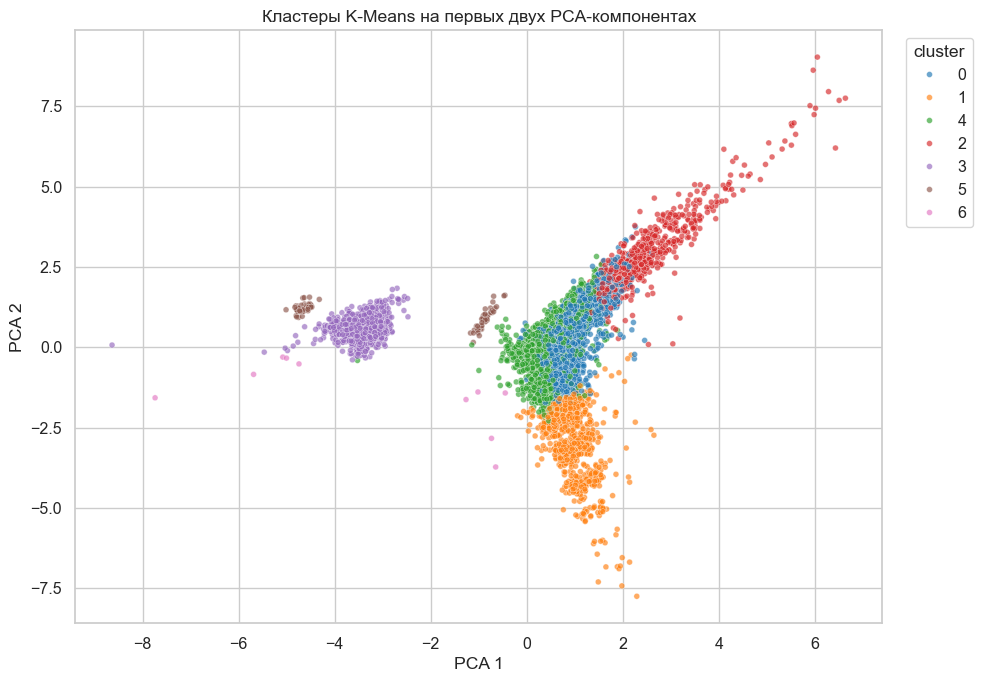

In [ ]:
sample_plot_idx = rng.choice(len(result), size=min(8000, len(result)), replace=False)
plot_df = pd.DataFrame({
    "pca_1": X_pca[sample_plot_idx, 0],
    "pca_2": X_pca[sample_plot_idx, 1],
    "cluster": result.loc[sample_plot_idx, "cluster"].astype(str).to_numpy(),
    "location_cluster": result.loc[sample_plot_idx, "location_cluster"].to_numpy(),
    "type_house": result.loc[sample_plot_idx, "type_house"].to_numpy(),
})

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(data=plot_df, x="pca_1", y="pca_2", hue="cluster", s=18, alpha=0.65, ax=ax, palette="tab10")
ax.set_title("Кластеры K-Means на первых двух PCA-компонентах")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.legend(title="cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
numeric_profile_cols = [
    "sum",
    "min_days",
    "amt_reviews",
    "avg_reviews",
    "total_host",
    TARGET,
]

cluster_profile = result.groupby("cluster").agg(
    count=("_id", "size"),
    mean_sum=("sum", "mean"),
    median_sum=("sum", "median"),
    mean_min_days=("min_days", "mean"),
    mean_amt_reviews=("amt_reviews", "mean"),
    mean_avg_reviews=("avg_reviews", "mean"),
    mean_total_host=("total_host", "mean"),
    mean_target=(TARGET, "mean"),
    median_target=(TARGET, "median"),
    top_borough=("location_cluster", lambda x: x.mode().iloc[0]),
    top_location=("location", lambda x: x.mode().iloc[0]),
    top_type_house=("type_house", lambda x: x.mode().iloc[0]),
).reset_index()

cluster_profile["share"] = cluster_profile["count"] / len(result)
display(cluster_profile)

,cluster,count,mean_sum,median_sum,mean_min_days,mean_amt_reviews,mean_avg_reviews,mean_total_host,mean_target,median_target,top_borough,top_location,top_type_house,share
0,0,10779,111.682624,85.0,4.919751,20.568606,1.364493,2.865201,128.759347,82.0,Brooklyn,Bedford-Stuyvesant,Private room,0.293938
1,1,5456,149.207661,105.0,5.787207,6.085227,0.137659,2.601723,36.012830,0.0,Manhattan,Williamsburg,Entire home/apt,0.148782
2,2,2816,129.247869,103.0,2.864702,146.939986,3.916065,1.761009,167.019531,173.0,Brooklyn,Bedford-Stuyvesant,Entire home/apt,0.076791
3,3,7242,186.480392,117.0,9.619442,0.000000,NaN,6.188622,99.106600,1.0,Manhattan,Williamsburg,Entire home/apt,0.197486
4,4,9913,173.234238,130.0,6.650863,19.094522,1.314083,4.525673,124.367598,73.0,Manhattan,Harlem,Entire home/apt,0.270323
5,5,414,272.794686,253.0,20.925121,2.434783,1.741236,286.613527,282.743961,317.0,Manhattan,Financial District,Entire home/apt,0.011290
6,6,51,326.372549,130.0,425.843137,6.882353,0.377407,1.352941,253.196078,358.0,Manhattan,Greenwich Village,Entire home/apt,0.001391


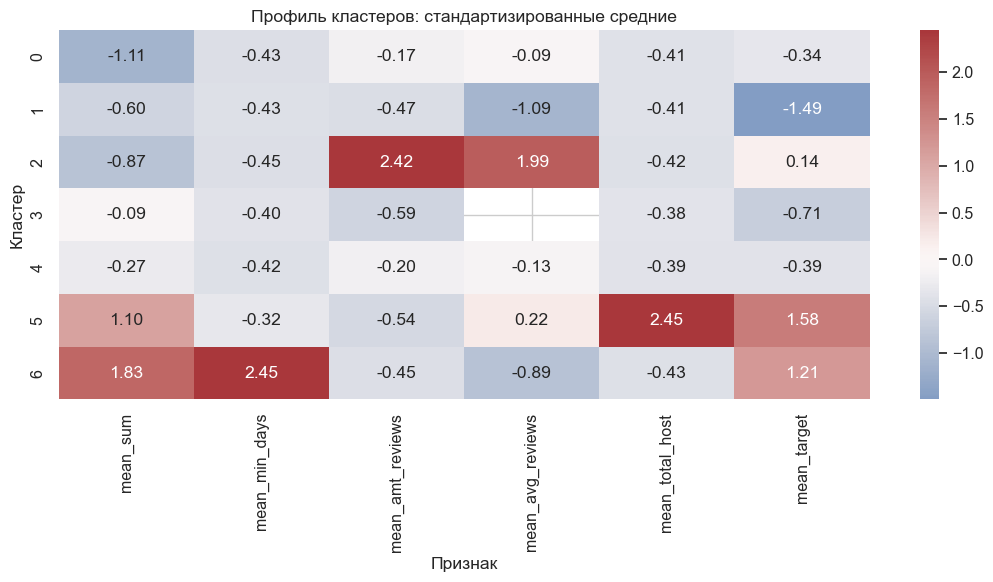

In [ ]:
heatmap_cols = [
    "mean_sum",
    "mean_min_days",
    "mean_amt_reviews",
    "mean_avg_reviews",
    "mean_total_host",
    "mean_target",
]

heatmap_data = cluster_profile.set_index("cluster")[heatmap_cols]
heatmap_z = (heatmap_data - heatmap_data.mean()) / heatmap_data.std(ddof=0)

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(heatmap_z, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Профиль кластеров: стандартизированные средние")
ax.set_xlabel("Признак")
ax.set_ylabel("Кластер")
plt.tight_layout()
plt.show()

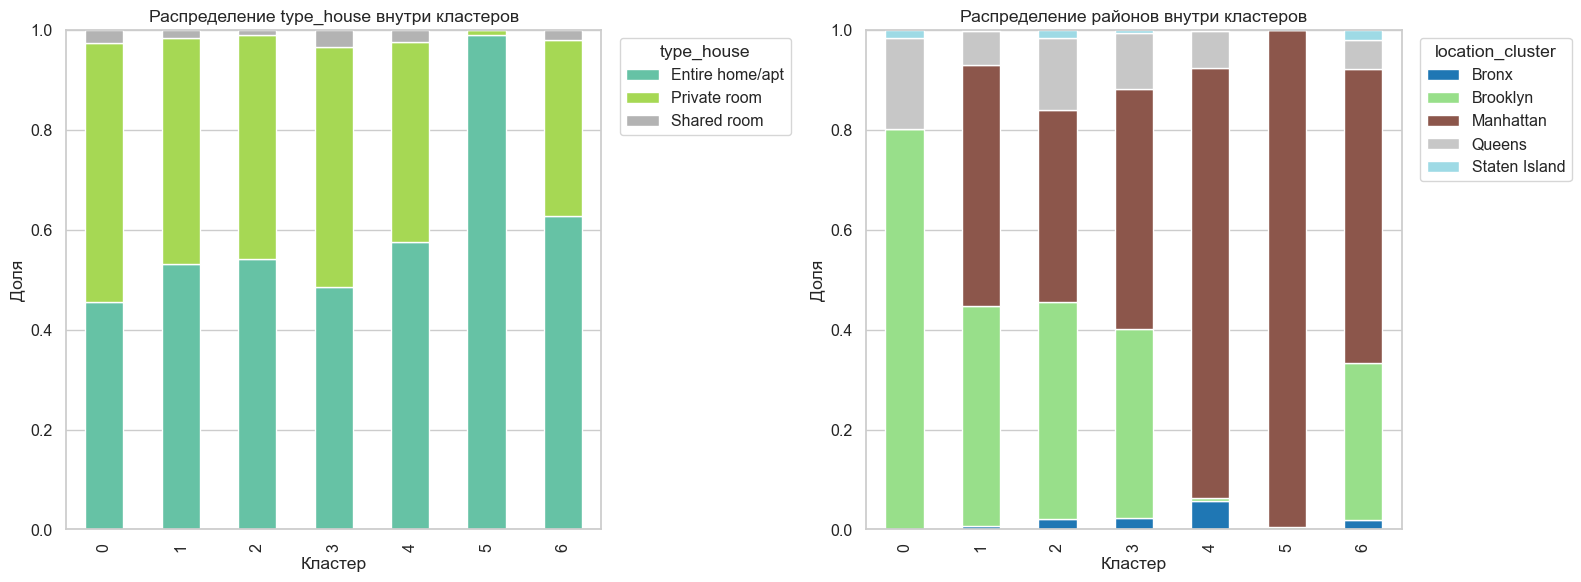

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

type_dist = pd.crosstab(result["cluster"], result["type_house"], normalize="index")
type_dist.plot(kind="bar", stacked=True, ax=axes[0], colormap="Set2")
axes[0].set_title("Распределение type_house внутри кластеров")
axes[0].set_xlabel("Кластер")
axes[0].set_ylabel("Доля")
axes[0].legend(title="type_house", bbox_to_anchor=(1.02, 1), loc="upper left")

borough_dist = pd.crosstab(result["cluster"], result["location_cluster"], normalize="index")
borough_dist.plot(kind="bar", stacked=True, ax=axes[1], colormap="tab20")
axes[1].set_title("Распределение районов внутри кластеров")
axes[1].set_xlabel("Кластер")
axes[1].set_ylabel("Доля")
axes[1].legend(title="location_cluster", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

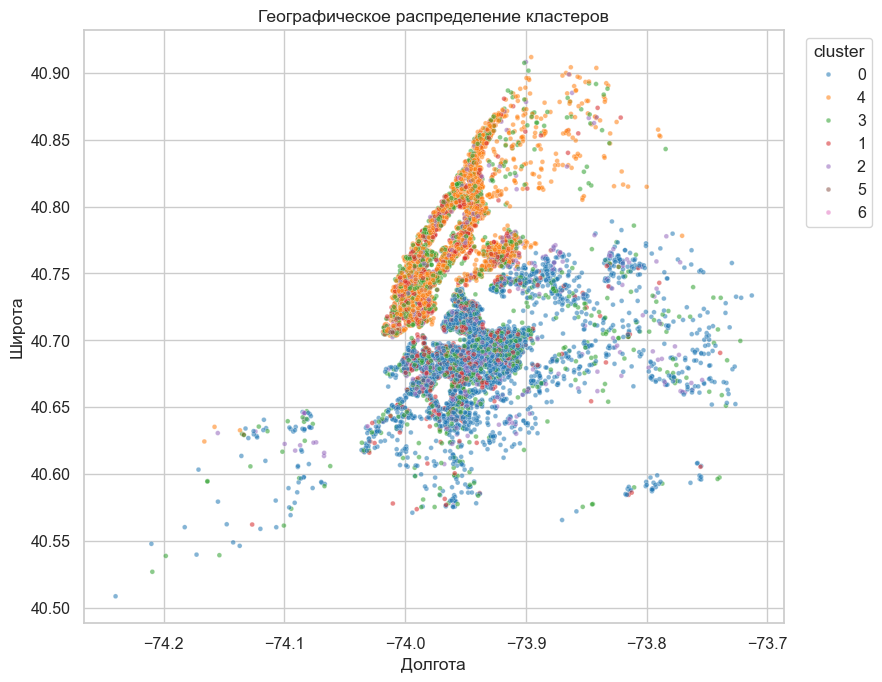

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
geo_sample = result.sample(min(12000, len(result)), random_state=RANDOM_STATE)
sns.scatterplot(
    data=geo_sample,
    x="lon",
    y="lat",
    hue=geo_sample["cluster"].astype(str),
    s=12,
    alpha=0.55,
    palette="tab10",
    ax=ax,
)
ax.set_title("Географическое распределение кластеров")
ax.set_xlabel("Долгота")
ax.set_ylabel("Широта")
ax.legend(title="cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 8. Итог

В работе выполнена кластеризация объявлений Airbnb без использования `target` при обучении.
Были рассмотрены разные семейства методов: разделительный K-Means, вероятностный GMM,
иерархический Agglomerative Clustering и плотностный DBSCAN.

Финальный выбор — K-Means с `k=7`. Причина выбора: `k=7` дает лучший Davies-Bouldin среди
рассмотренных значений `k`, а K-Means лучше подходит для полного датасета по скорости,
масштабируемости и интерпретируемости. DBSCAN и Agglomerative полезны для сравнения, но менее
удобны как финальный метод на всех данных. GMM оказался слабее по метрикам при 7 компонентах.

Главный содержательный результат: данные разделяются на сегменты по отзывам, цене,
минимальному сроку аренды, типу жилья, району и масштабу хоста. Это показывает, что
кластеризация нашла не случайные группы, а интерпретируемые типы объявлений.